# Model Interpretability & Error Analysis

Single-stage BG/NBD + ML ensemble pipeline.  
This notebook covers:
1. SHAP global importance for the single-stage LightGBM model
2. `p_alive` SHAP dependence plot — where does BG/NBD rank vs RFM features?
3. Quarterly feature importance — which quarter matters most?
4. Waterfall plots for one churned and one high-value customer
5. Error analysis: residuals, MAE by segment, MAE by revenue decile


In [11]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# Load v3 features (90 features including BG/NBD + Kevin's EDA features)
features = pd.read_csv("../data/customer_features_v3.csv")
train    = pd.read_csv("../data/customer_clv_train.csv")
df = train.merge(features, on="cust_id", how="left")

# Load saved config from notebook 04
feature_cols_ml  = joblib.load("../models/feature_cols_ml.pkl")
ensemble_weights = joblib.load("../models/ml_ensemble_weights.pkl")
alpha_opt        = joblib.load("../models/blend_alpha.pkl")
USE_BLEND        = joblib.load("../models/use_blend.pkl")
USE_TS_ML_BLEND  = joblib.load("../models/use_ts_ml_blend.pkl")
beta_ts_ml       = joblib.load("../models/blend_beta.pkl")
w_lgb = ensemble_weights["w_lgb"]
w_xgb = ensemble_weights["w_xgb"]
w_cat = ensemble_weights["w_cat"]

# Fill any NaNs
df[feature_cols_ml] = df[feature_cols_ml].fillna(0)

# Same 80/20 split as notebook 04
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)
df_val = df_val.reset_index(drop=True)

X_val    = df_val[feature_cols_ml].values
y_val    = df_val["revenue_2018_2019"].values

print(f"Val set: {len(df_val)} customers  |  Feature count: {len(feature_cols_ml)}")
print(f"Strategy: USE_TS_ML_BLEND={USE_TS_ML_BLEND}  β={beta_ts_ml:.4f}  |  USE_BLEND={USE_BLEND}  α={alpha_opt:.4f}")


Val set: 23319 customers  |  Feature count: 90
Strategy: USE_TS_ML_BLEND=True  β=0.0400  |  USE_BLEND=True  α=0.0000


## 1. SHAP — Single-Stage LightGBM (Global Importance)

SHAP (SHapley Additive exPlanations) shows how each feature pushes a prediction away from the base value.  
We use a random sample of 500 customers from the validation set for speed.


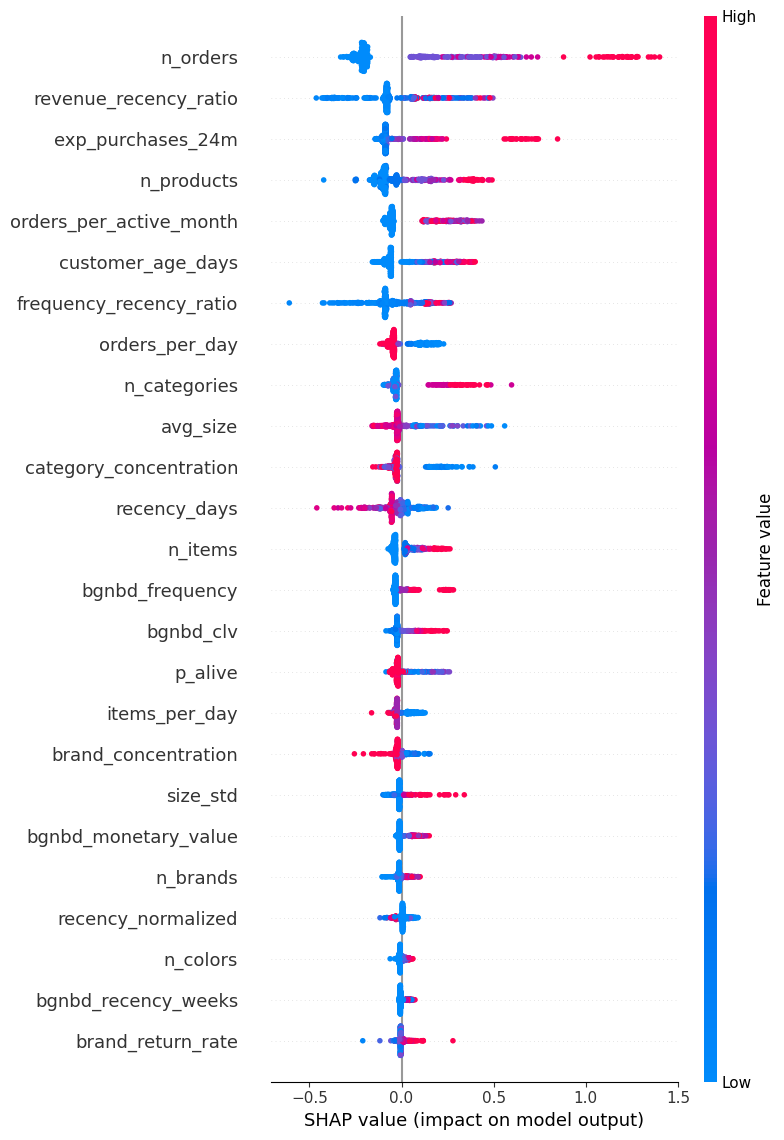

In [12]:
lgb_model = joblib.load("../models/ml_lgb_model.pkl")

# Sample 500 rows for SHAP speed
np.random.seed(42)
shap_idx  = np.random.choice(len(X_val), size=min(500, len(X_val)), replace=False)
X_shap    = pd.DataFrame(X_val[shap_idx], columns=feature_cols_ml)

explainer  = shap.TreeExplainer(lgb_model)
shap_vals  = explainer.shap_values(X_shap)

# Beeswarm summary — top 25 features
shap.summary_plot(shap_vals, X_shap, max_display=25, show=True)


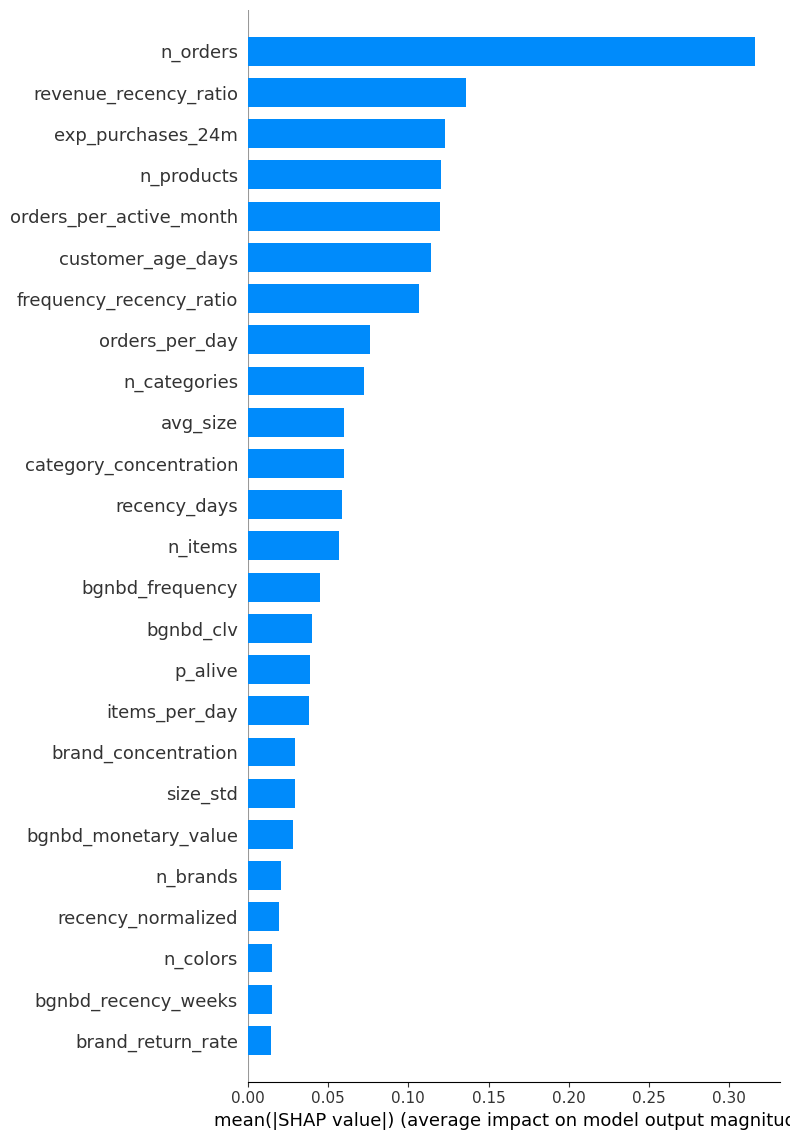

In [13]:
# Bar chart: mean |SHAP| per feature (top 25)
shap.summary_plot(shap_vals, X_shap, plot_type="bar", max_display=25, show=True)


## 2. `p_alive` SHAP Dependence Plot

Where does the BG/NBD `p_alive` probability rank among all features?  
How does higher `p_alive` translate to higher predicted CLV?


# p_alive SHAP dependence — coloured by recency_days


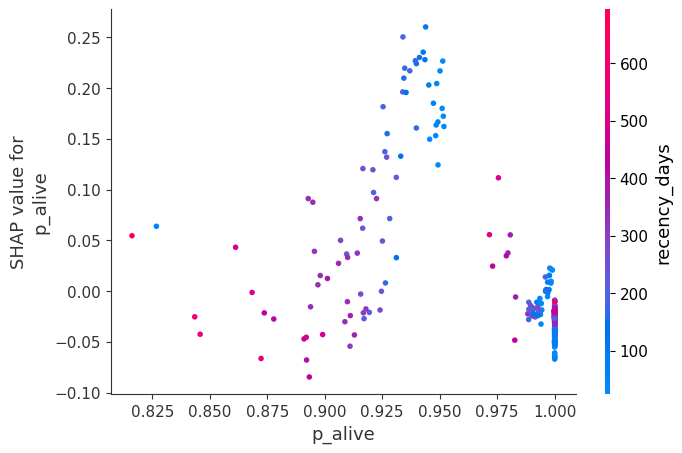

p_alive mean |SHAP|: 0.0385  (rank #16 of 90)


In [14]:
if "p_alive" in feature_cols_ml:
    shap.dependence_plot("p_alive", shap_vals, X_shap,
                         interaction_index="recency_days" if "recency_days" in feature_cols_ml else "auto",
                         show=True)
    
    # Rank p_alive by mean |SHAP|
    mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_cols_ml)
    rank = mean_abs_shap.rank(ascending=False).astype(int)
    print(f"p_alive mean |SHAP|: {mean_abs_shap['p_alive']:.4f}  (rank #{rank['p_alive']} of {len(feature_cols_ml)})")
else:
    print("p_alive not found in feature list — run notebook 03 first.")

## 3. Quarterly Feature Importance

Which quarter's revenue/orders/returns matters most for predicting 2018-2019 CLV?


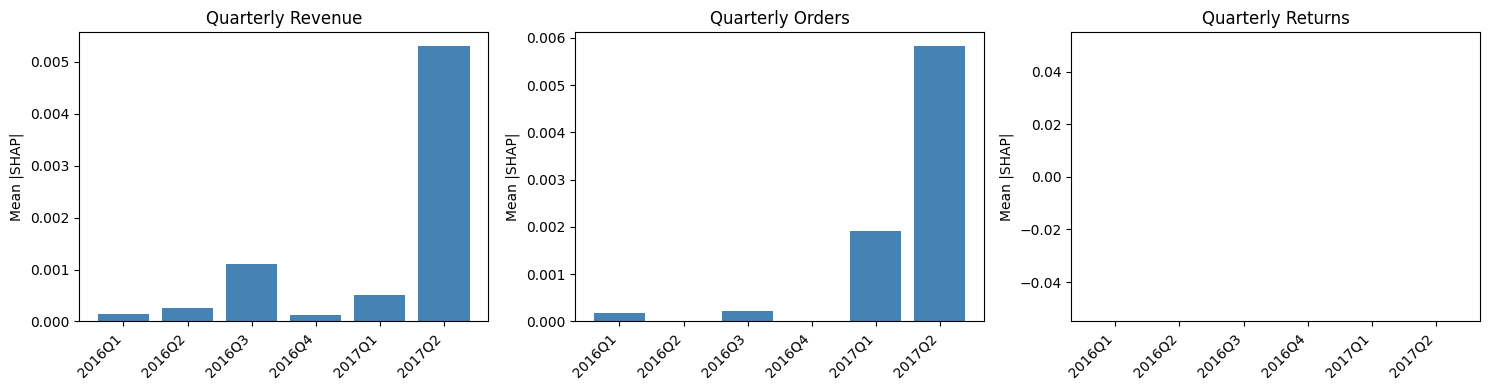

In [15]:
mean_abs_shap = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_cols_ml)

# Quarterly revenue features
q_rev_cols = [c for c in feature_cols_ml if c.startswith("q_rev_")]
q_ord_cols = [c for c in feature_cols_ml if c.startswith("q_ord_")]
q_ret_cols = [c for c in feature_cols_ml if c.startswith("q_ret_")]

if q_rev_cols:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, cols, title in [
        (axes[0], q_rev_cols, "Quarterly Revenue"),
        (axes[1], q_ord_cols, "Quarterly Orders"),
        (axes[2], q_ret_cols, "Quarterly Returns"),
    ]:
        if cols:
            vals = mean_abs_shap[cols].sort_index()
            ax.bar(range(len(vals)), vals.values, color="steelblue", edgecolor="none")
            ax.set_xticks(range(len(vals)))
            ax.set_xticklabels([c.replace("q_rev_","").replace("q_ord_","").replace("q_ret_","")
                                 for c in vals.index], rotation=45, ha="right")
            ax.set_title(title)
            ax.set_ylabel("Mean |SHAP|")
    plt.tight_layout()
    plt.show()
else:
    print("No quarterly features found — check that notebook 02 was run.")


## 4. Waterfall Plots — One Churned vs One High-Value Customer


# Pick one churned (revenue=0) and one high-value customer from the SHAP sample


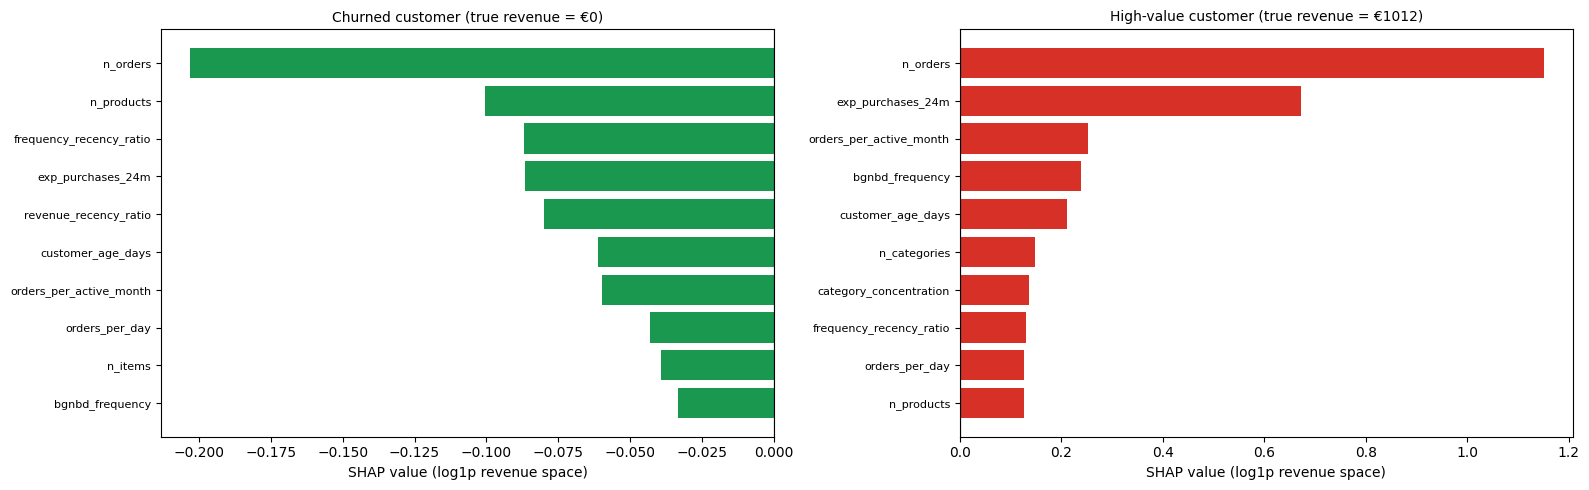

In [16]:
shap_df = X_shap.copy()
shap_df["revenue"] = y_val[shap_idx]

churned_idx   = shap_df[shap_df["revenue"] == 0].index[0]
highval_idx   = shap_df["revenue"].idxmax()

expected_val  = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = float(expected_val[0])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, idx, label in [
    (axes[0], churned_idx, "Churned"),
    (axes[1], highval_idx, "High-value"),
]:
    # Build title inside the loop — idx is now defined
    title = f"{label} customer (true revenue = €{shap_df.loc[idx, 'revenue']:.0f})"
    row_pos = shap_df.index.get_loc(idx)
    sv       = shap_vals[row_pos]
    top_n    = 10
    order    = np.argsort(np.abs(sv))[::-1][:top_n]
    top_sv   = sv[order]
    top_feat = [feature_cols_ml[i] for i in order]

    colors = ["#d73027" if v > 0 else "#1a9850" for v in top_sv]
    ax.barh(range(top_n), top_sv[::-1], color=colors[::-1], edgecolor="none")
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_feat[::-1], fontsize=8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("SHAP value (log1p revenue space)")
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

## 5. Error Analysis


In [17]:
# Generate final validation predictions (mirrors strategy selection in notebook 04/05)
ml_lgb = joblib.load("../models/ml_lgb_model.pkl")
ml_xgb = joblib.load("../models/ml_xgb_model.pkl")
ml_cat = joblib.load("../models/ml_cat_model.pkl")

val_pred_lgb = np.expm1(ml_lgb.predict(X_val)).clip(0)
val_pred_xgb = np.expm1(ml_xgb.predict(X_val)).clip(0)
val_pred_cat = np.expm1(ml_cat.predict(X_val)).clip(0)
val_pred_ml  = w_lgb * val_pred_lgb + w_xgb * val_pred_xgb + w_cat * val_pred_cat

bgnbd_val      = df_val["bgnbd_clv"].fillna(0).clip(0).values
val_pred_bgnbd = alpha_opt * bgnbd_val + (1 - alpha_opt) * val_pred_ml

# Two-stage × ML ensemble blend
churn_clf  = joblib.load("../models/churn_clf_model.pkl")
cond_reg   = joblib.load("../models/cond_reg_model.pkl")
p_return_val     = churn_clf.predict_proba(X_val)[:, 1]
cond_rev_val     = np.expm1(cond_reg.predict(X_val)).clip(0)
val_pred_twostage = p_return_val * cond_rev_val
val_pred_ts_blend = beta_ts_ml * val_pred_twostage + (1 - beta_ts_ml) * val_pred_ml

# Select strategy (mirrors notebook 05 logic)
if USE_TS_ML_BLEND:
    final_pred = val_pred_ts_blend
    strategy   = f"Two-stage × ML blend (β={beta_ts_ml:.2f})"
elif USE_BLEND:
    final_pred = val_pred_bgnbd
    strategy   = f"ML + BG/NBD (α={alpha_opt:.2f})"
else:
    final_pred = val_pred_ml
    strategy   = "ML weighted ensemble"

mae_val  = mean_absolute_error(y_val, final_pred)
corr_val, _ = spearmanr(y_val, final_pred)
print(f"Strategy:            {strategy}")
print(f"Validation MAE:      {mae_val:.2f}")
print(f"Validation Spearman: {corr_val:.4f}")


Strategy:            Two-stage × ML blend (β=0.04)
Validation MAE:      62.69
Validation Spearman: 0.4032


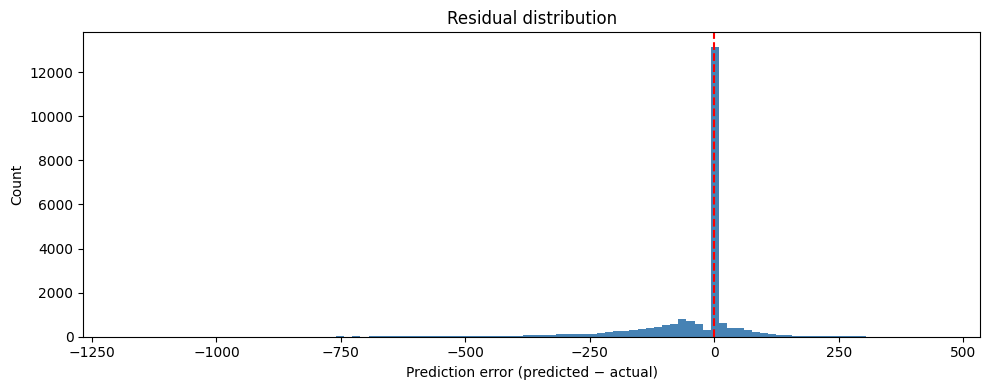

Mean error:   -45.48
Median error: 0.79


In [18]:
# Residual distribution
residuals = final_pred - y_val
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=100, edgecolor="none", color="steelblue")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Prediction error (predicted − actual)")
plt.ylabel("Count")
plt.title("Residual distribution")
plt.tight_layout()
plt.show()
print(f"Mean error:   {residuals.mean():.2f}")
print(f"Median error: {np.median(residuals):.2f}")


In [19]:
# MAE: churned vs retained
err_df = pd.DataFrame({"true": y_val, "pred": final_pred})
err_df["abs_error"] = np.abs(err_df["pred"] - err_df["true"])
err_df["churned"]   = (err_df["true"] == 0).astype(int)

mae_ch = err_df.loc[err_df["churned"] == 1, "abs_error"].mean()
mae_re = err_df.loc[err_df["churned"] == 0, "abs_error"].mean()
print(f"MAE — churned customers  (true revenue = 0): {mae_ch:.2f}")
print(f"MAE — retained customers (revenue > 0):      {mae_re:.2f}")


MAE — churned customers  (true revenue = 0): 9.19
MAE — retained customers (revenue > 0):      155.07


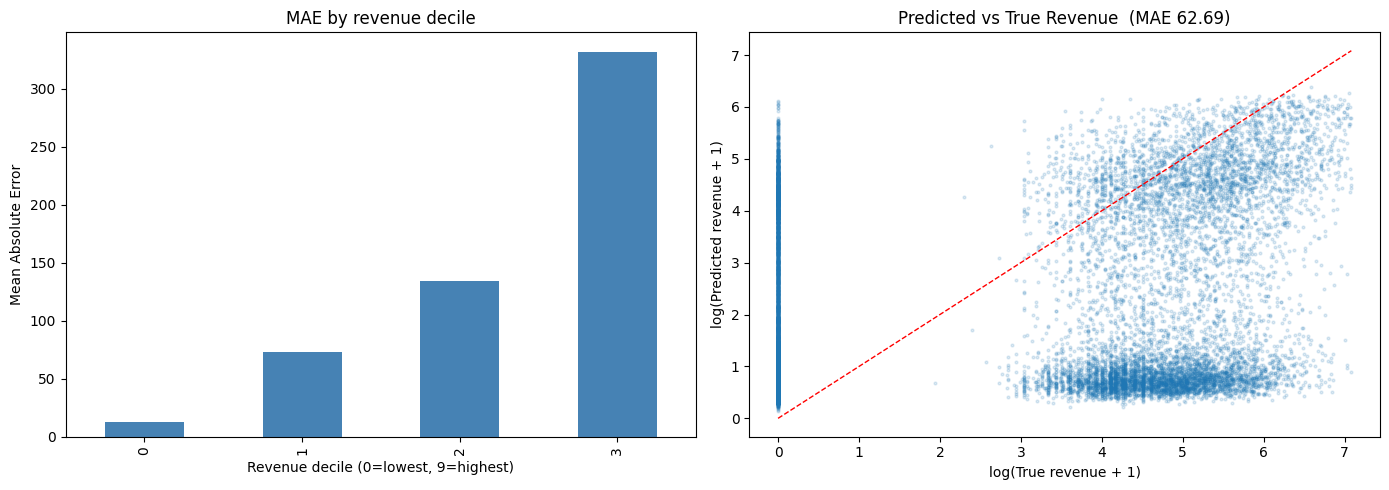

In [20]:
# MAE by revenue decile
err_df["revenue_decile"] = pd.qcut(err_df["true"], q=10, labels=False, duplicates="drop")
decile_mae = err_df.groupby("revenue_decile")["abs_error"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decile bar
decile_mae.plot(kind="bar", color="steelblue", edgecolor="none", ax=axes[0])
axes[0].set_xlabel("Revenue decile (0=lowest, 9=highest)")
axes[0].set_ylabel("Mean Absolute Error")
axes[0].set_title("MAE by revenue decile")

# Scatter predicted vs actual
axes[1].scatter(np.log1p(err_df["true"]), np.log1p(err_df["pred"]), alpha=0.15, s=4)
lim = max(np.log1p(err_df["true"]).max(), np.log1p(err_df["pred"]).max())
axes[1].plot([0, lim], [0, lim], "r--", lw=1)
axes[1].set_xlabel("log(True revenue + 1)")
axes[1].set_ylabel("log(Predicted revenue + 1)")
axes[1].set_title(f"Predicted vs True Revenue  (MAE {mae_val:.2f})")

plt.tight_layout()
plt.show()
